# How far ahead does the MILP need to look?

Six ways of using the *same* continuous MILP formulation, on the same household, the same
30 kWh battery and the same GEN-I Dinamični samooskrba tariff, over the full year:

| strategy | plans over | then executes |
|---|---|---|
| `day_block` | 1 day (96 intervals) | the whole day, then re-plans |
| `day_receding` | 1 day | **the first interval only**, then re-plans (MPC) |
| `week_block` | 1 week (672 intervals) | the whole week |
| `week_receding` | 1 week | the first interval only (MPC) |
| `month_block` | 1 calendar month | the whole month |
| `full_period` | the whole year (35 136 intervals, 0.1 % MIP gap) | everything |

`full_period` is the perfect-foresight optimum — nothing can beat it. The gap between it and
the others is the price of a shorter planning horizon; the gap between a `_block` strategy and
its `_receding` twin is what re-planning every interval buys at the same horizon length.

**Everything is priced by one shared evaluator.** The MILP only ever produces a *dispatch*;
`Horizon_Comparison.price_interval` then walks the executed trajectory interval by interval
carrying a single running peak state. This matters because the excess-power (konica) charge is
a running maximum over the whole year — if each strategy priced its own peaks they would not
be comparable. The evaluator was checked against `run_milp_benchmark`'s internal pricing on a
one-week solve: identical to 0.00e+00 EUR.

**The controller knows its true peak state.** `run_milp_benchmark` normally seeds a sub-solve
from `env.compute_seed_peak_kw(start_idx)` — the peak a household *with no battery* would have
reached by then. For a trajectory that has been shaving peaks all year that is simply wrong, so
`Horizon_Comparison._PeakSeedView` feeds each sub-solve the peak the executed trajectory has
actually set.

**State of charge.** Every solve starts at the SOC the trajectory has reached and must end its
horizon at 50 % of capacity (15 kWh), so no strategy can profit by selling off its opening
charge, and all six start and finish the year at 15 kWh.

In [1]:
### Imports
import time
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import importlib
import Horizon_Comparison as hc
hc = importlib.reload(hc)

print("Horizon_Comparison loaded.")

Horizon_Comparison loaded.


## 1. Configuration

The study parameters live in `Horizon_Comparison.py` so the notebook and the batch script
cannot drift apart. `RUN_BATCH = True` recomputes everything — that is ~3 h per household
(the week-horizon MPC alone is 35 136 solves of 672 intervals each), so by default the
notebook reads the CSVs the batch script already wrote.

In [2]:
HOUSEHOLD_IDS = list(range(1, 31))
RESULTS_DIR = hc.RESULTS_DIR
RUN_BATCH = False          # True -> recompute (~3 h per household, resumable)
N_WORKERS = 10

print(f"dataset            : {hc.DATASET_NAME}, households {HOUSEHOLD_IDS[0]}-{HOUSEHOLD_IDS[-1]}")
print(f"tariff             : {hc.PAKET_ID} ({hc.PRICING_SCHEME}), regime {hc.PRICING_REFERENCE_YEAR}")
print(f"battery            : {hc.BATTERY_CAPACITY_KWH:.0f} kWh, "
      f"{min(hc.C_RATE * hc.BATTERY_CAPACITY_KWH, hc.INVERTER_MAX_KW):.1f} kW, "
      f"eff {hc.CHARGE_EFFICIENCY:.2f}/{hc.DISCHARGE_EFFICIENCY:.2f}")
print(f"SOC start = end    : {hc.SOC_FRACTION:.0%} of capacity "
      f"({hc.SOC_FRACTION * hc.BATTERY_CAPACITY_KWH:.1f} kWh), enforced on every solve")
print(f"peak reset         : {hc.PEAK_RESET_MONTHS} (None = one annual ratchet)")
print(f"results            : {RESULTS_DIR}")

dataset            : Fluvius_PV, households 1-30
tariff             : GENI_SAMO_DINAMICNI (si_samooskrba), regime 2026
battery            : 30 kWh, 11.0 kW, eff 0.95/0.95
SOC start = end    : 50% of capacity (15.0 kWh), enforced on every solve
peak reset         : None (None = one annual ratchet)
results            : /Users/summerscholl/Documents/Andraz/Energy_Community/Results/Horizon_Comparison


## 2. Load results

In [3]:
if RUN_BATCH:
    hc.run_batch(HOUSEHOLD_IDS, output_dir=RESULTS_DIR, n_workers=N_WORKERS)

df_all = hc.collect_results(RESULTS_DIR)
if df_all.empty:
    raise SystemExit(
        f"No results in {RESULTS_DIR}.\n"
        f"Run  python Horizon_Comparison.py --users 30 --workers 10  (~10 h), "
        f"or set RUN_BATCH = True above."
    )

# The batch writes each household's CSV after every finished strategy, so this
# notebook is readable at any point during the run.
expected = list(hc.STRATEGIES)
done = {h: set(g) for h, g in df_all.groupby("Household")["Strategy"]}
progress = pd.DataFrame(
    [[("done" if s in done[h] else "-") for s in expected] for h in sorted(done)],
    index=pd.Index(sorted(done), name="Household"), columns=expected,
)
complete = [h for h in sorted(done) if set(expected) <= done[h]]

print(f"{len(complete)} of {len(HOUSEHOLD_IDS)} households complete "
      f"({len(df_all)} of {len(HOUSEHOLD_IDS) * len(expected)} runs finished)")
if len(complete) < len(done):
    print("\nBatch still in flight:")
    print(progress.to_string())

if not complete:
    raise SystemExit(
        "No household has all six strategies yet, so there is nothing to compare against "
        "the whole-year optimum. Re-run this notebook once the batch has finished a "
        "household (week_receding is the slow one, ~2.7 h)."
    )

# Only fully solved households enter the comparison, so every row of the table
# is averaged over the same set of users.
df_all = df_all[df_all["Household"].isin(complete)].copy()
print(f"\nComparing {len(complete)} households x {len(expected)} strategies "
      f"= {len(df_all)} runs, {df_all['N_Solves'].sum():,.0f} MILP solves, "
      f"{df_all['Runtime_s'].sum() / 3600:.1f} solver-hours.")

30 of 30 households complete (180 of 180 runs finished)

Comparing 30 households x 6 strategies = 180 runs, 2,121,060 MILP solves, 111.0 solver-hours.


## 3. The comparison table

`Saving_Captured_pct` is the share of the *achievable* saving a strategy realizes:

    (no-battery cost − strategy cost) / (no-battery cost − full-period optimum)

so `full_period` is 100 % by construction and anything below is what the shorter horizon
costs. `Gap_to_Optimum_EUR` is the same thing in euros per year.

In [4]:
summary, df_scored = hc.summarize(df_all)
summary_display = summary.rename(columns={
    "Cost_EUR": "Cost [EUR/a]",
    "Savings_EUR": "Saving [EUR/a]",
    "Saving_Captured_pct": "Saving captured [%]",
    "Gap_to_Optimum_EUR": "Gap to optimum [EUR/a]",
    "Worst_Gap_EUR": "Worst-case gap [EUR/a]",
    "Energy_EUR": "Energy part [EUR/a]",
    "Power_EUR": "Peak part [EUR/a]",
    "Cycles": "Full cycles/a",
    "Peak_kW": "Peak import [kW]",
    "Solves": "MILP solves",
    "Runtime_s": "Solver time [s]",
})
summary_display.round(2)

,Households,Cost [EUR/a],Saving [EUR/a],Saving captured [%],Gap to optimum [EUR/a],Worst-case gap [EUR/a],Energy part [EUR/a],Peak part [EUR/a],Full cycles/a,Peak import [kW],MILP solves,Solver time [s]
Strategy,,,,,,,,,,,,
day_block,30,-250.09,572.78,81.91,125.18,143.84,-419.05,0.70,216.35,12.26,366.0,23.08
day_receding,30,-320.79,643.49,92.06,54.47,82.55,-490.06,1.01,204.69,12.30,35135.0,2014.72
week_block,30,-335.20,657.89,94.17,40.07,55.42,-504.61,1.15,214.73,12.27,53.0,19.22
week_receding,30,-340.82,663.52,94.97,34.44,52.79,-510.90,1.82,208.26,12.44,35135.0,11136.44
month_block,30,-359.88,682.58,97.77,15.39,19.09,-530.55,2.41,221.35,12.15,12.0,29.23
full_period,30,-375.27,697.96,100.00,0.00,0.00,-552.71,9.19,232.05,12.37,1.0,94.31


In [5]:
### Per-household cost, one column per strategy
pivot = (
    df_scored.pivot(index="Household", columns="Strategy", values="Cost_EUR")
    .reindex(columns=[s for s in hc.STRATEGIES if s in df_scored["Strategy"].unique()])
)
pivot.insert(0, "no_battery", df_scored.groupby("Household")["No_Battery_EUR"].first())
pivot.round(2)

Strategy,no_battery,day_block,day_receding,week_block,week_receding,month_block,full_period
Household,,,,,,,
1,419.64,-235.49,-307.32,-317.51,-322.12,-333.63,-348.03
2,220.38,-369.77,-440.05,-457.42,-462.43,-483.49,-498.68
3,109.37,-457.65,-521.35,-544.32,-549.15,-575.49,-591.52
4,272.44,-226.78,-292.69,-313.63,-319.02,-347.25,-364.78
5,237.66,-370.31,-446.08,-456.75,-463.05,-474.60,-489.56
6,852.27,108.51,24.50,28.52,20.35,22.49,16.46
7,219.61,-357.07,-423.22,-444.43,-448.94,-474.42,-490.69
8,474.07,-75.36,-142.71,-156.40,-162.56,-185.71,-202.07
9,248.83,-315.78,-386.33,-401.19,-407.18,-428.55,-443.54


In [6]:
### Per-household gap to the perfect-foresight optimum [EUR/a]
gap = (
    df_scored.pivot(index="Household", columns="Strategy", values="Gap_to_Optimum_EUR")
    .reindex(columns=[s for s in hc.STRATEGIES if s in df_scored["Strategy"].unique()])
)
gap.round(2)

Strategy,day_block,day_receding,week_block,week_receding,month_block,full_period
Household,,,,,,
1,112.54,40.71,30.51,25.91,14.40,0.0
2,128.91,58.64,41.26,36.25,15.20,0.0
3,133.86,70.16,47.20,42.37,16.02,0.0
4,138.00,72.09,51.15,45.75,17.53,0.0
5,119.26,43.48,32.82,26.52,14.96,0.0
6,92.06,8.04,12.06,3.89,6.03,0.0
7,133.62,67.47,46.26,41.75,16.27,0.0
8,126.72,59.37,45.67,39.51,16.36,0.0
9,127.76,57.21,42.35,36.35,14.99,0.0


## 4. Plots

In [7]:
### Shared chart styling
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})

STRAT_ORDER = [s for s in hc.STRATEGIES if s in df_scored["Strategy"].unique()]
LABEL = {
    "day_block": "day, block",
    "day_receding": "day, receding",
    "week_block": "week, block",
    "week_receding": "week, receding",
    "month_block": "month, block",
    "full_period": "whole year",
}
print("Style ready.")

Style ready.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


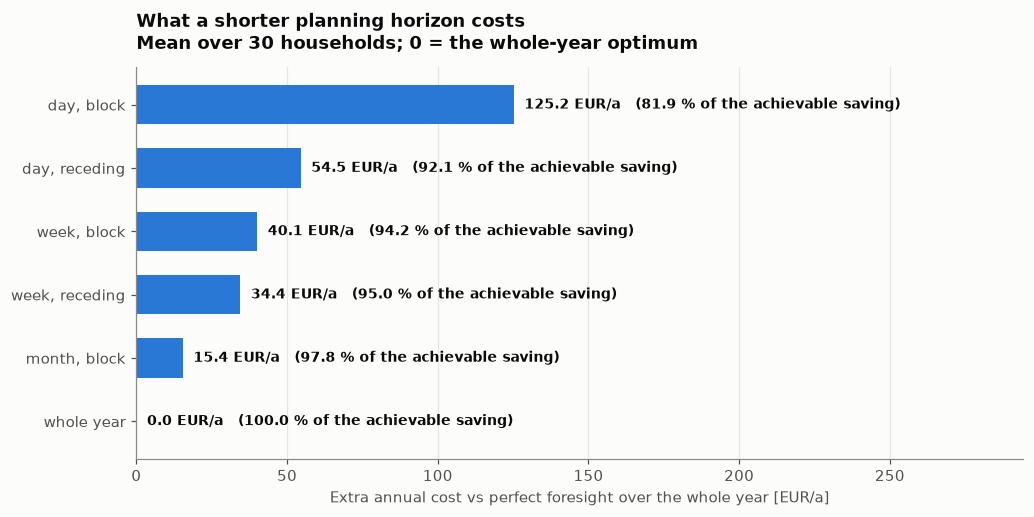

In [8]:
### What a shorter planning horizon costs, in euros per year
fig, ax = plt.subplots(figsize=(9.5, 4.8))

gaps = summary.loc[STRAT_ORDER, "Gap_to_Optimum_EUR"]
pcts = summary.loc[STRAT_ORDER, "Saving_Captured_pct"]
ypos = np.arange(len(STRAT_ORDER))[::-1]

ax.barh(ypos, gaps, height=0.62, color=SERIES[0])
for y, gap_v, pct_v in zip(ypos, gaps, pcts):
    ax.annotate(f"{gap_v:,.1f} EUR/a   ({pct_v:.1f} % of the achievable saving)",
                xy=(gap_v, y), xytext=(7, 0), textcoords="offset points",
                va="center", color=INK, fontsize=9, fontweight="semibold")

ax.axvline(0, color=MUTED, lw=1.1, ls="--")
ax.set_yticks(ypos, [LABEL[s] for s in STRAT_ORDER])
ax.set_xlim(0, float(gaps.max()) * 2.35)
ax.set_xlabel("Extra annual cost vs perfect foresight over the whole year [EUR/a]")
ax.set_title("What a shorter planning horizon costs\n"
             f"Mean over {summary['Households'].iloc[0]:.0f} households; "
             "0 = the whole-year optimum")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

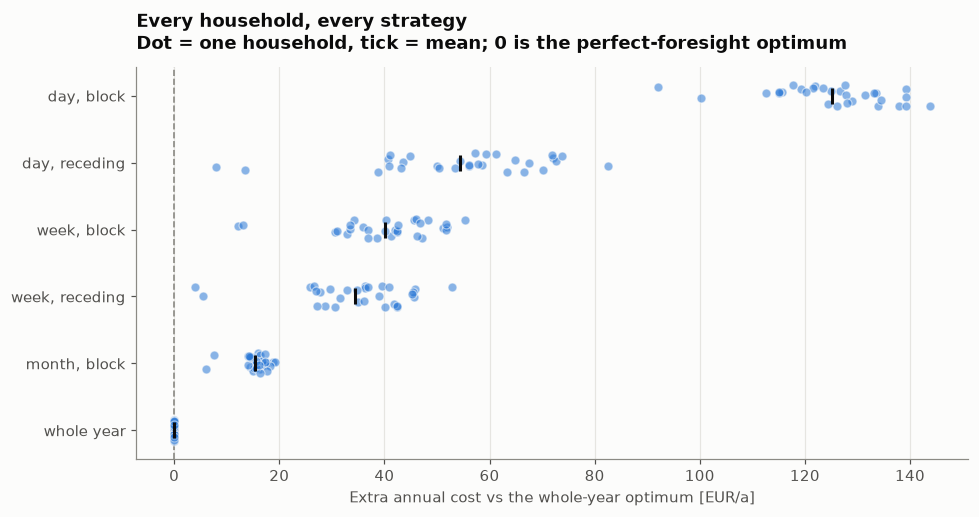

In [9]:
### Spread across households: gap to the optimum, one dot per household
fig, ax = plt.subplots(figsize=(9, 4.8))

rng = np.random.default_rng(0)
for i, strat in enumerate(STRAT_ORDER):
    y = len(STRAT_ORDER) - 1 - i
    vals = df_scored.loc[df_scored["Strategy"] == strat, "Gap_to_Optimum_EUR"]
    ax.scatter(vals, y + rng.uniform(-0.16, 0.16, len(vals)), s=34,
               color=SERIES[0], alpha=0.55, lw=0.8, edgecolor=SURFACE, zorder=3)
    ax.scatter([vals.mean()], [y], s=110, marker="|", color=INK, lw=2.0, zorder=4)

ax.axvline(0, color=MUTED, lw=1.1, ls="--")
ax.set_yticks(np.arange(len(STRAT_ORDER))[::-1], [LABEL[s] for s in STRAT_ORDER])
ax.set_xlabel("Extra annual cost vs the whole-year optimum [EUR/a]")
ax.set_title("Every household, every strategy\n"
             "Dot = one household, tick = mean; 0 is the perfect-foresight optimum")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

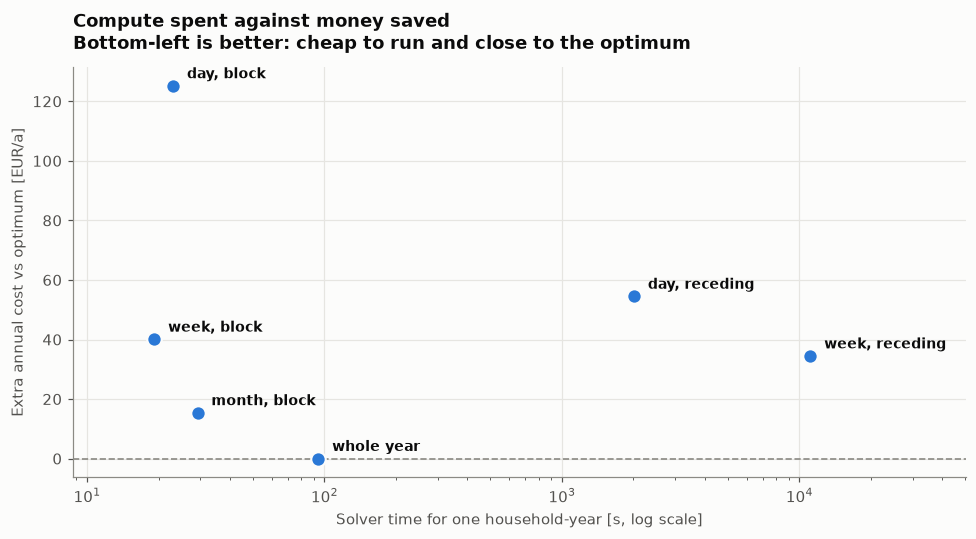

In [10]:
### What the extra compute buys
fig, ax = plt.subplots(figsize=(9, 5))

x = summary.loc[STRAT_ORDER, "Runtime_s"]
y = summary.loc[STRAT_ORDER, "Gap_to_Optimum_EUR"]
ax.scatter(x, y, s=90, color=SERIES[0], zorder=3, lw=1.4, edgecolor=SURFACE)
for strat, xi, yi in zip(STRAT_ORDER, x, y):
    ax.annotate(LABEL[strat], xy=(xi, yi), xytext=(9, 5), textcoords="offset points",
                color=INK, fontsize=9, fontweight="semibold")

ax.set_xscale("log")
ax.set_xlim(float(x.min()) / 2.2, float(x.max()) * 4.5)
ax.axhline(0, color=MUTED, lw=1.1, ls="--")
ax.set_xlabel("Solver time for one household-year [s, log scale]")
ax.set_ylabel("Extra annual cost vs optimum [EUR/a]")
ax.set_title("Compute spent against money saved\n"
             "Bottom-left is better: cheap to run and close to the optimum")
plt.tight_layout()
plt.show()

## 5. Read-out

In [11]:
best = summary["Gap_to_Optimum_EUR"].drop("full_period", errors="ignore").idxmin()
lines = [
    f"{summary['Households'].iloc[0]:.0f} households, {hc.BATTERY_CAPACITY_KWH:.0f} kWh battery, "
    f"full year, SOC pinned to {hc.SOC_FRACTION:.0%} at the start and end of every solve",
    f"Perfect foresight (whole year): {summary.loc['full_period', 'Cost_EUR']:8.2f} EUR/a mean cost",
    "",
    f"{'strategy':16s}{'cost':>10s}{'captured':>11s}{'gap':>10s}{'solves':>10s}{'time':>10s}",
]
for strat in STRAT_ORDER:
    r = summary.loc[strat]
    lines.append(
        f"{LABEL[strat]:16s}{r['Cost_EUR']:10.2f}{r['Saving_Captured_pct']:10.1f}%"
        f"{r['Gap_to_Optimum_EUR']:10.2f}{r['Solves']:10,.0f}{r['Runtime_s']:9.0f}s"
    )

lines += ["", "Effect of re-planning every interval instead of committing to the block:"]
for horizon in ("day", "week"):
    b, r = f"{horizon}_block", f"{horizon}_receding"
    if b in summary.index and r in summary.index:
        lines.append(
            f"   {horizon:5s}: {summary.loc[b, 'Cost_EUR']:8.2f} -> "
            f"{summary.loc[r, 'Cost_EUR']:8.2f} EUR/a "
            f"({summary.loc[b, 'Cost_EUR'] - summary.loc[r, 'Cost_EUR']:+.2f} EUR/a, "
            f"{summary.loc[r, 'Solves'] / summary.loc[b, 'Solves']:.0f}x the solves)"
        )

lines += ["", "Effect of a longer planning horizon at the same execution rule:"]
for a, b in (("day_block", "week_block"), ("week_block", "month_block"),
             ("month_block", "full_period"), ("day_receding", "week_receding")):
    if a in summary.index and b in summary.index:
        lines.append(f"   {LABEL[a]:16s} -> {LABEL[b]:16s} "
                     f"{summary.loc[a, 'Cost_EUR'] - summary.loc[b, 'Cost_EUR']:+8.2f} EUR/a")

lines += ["", f"Best non-clairvoyant strategy: {LABEL[best]} "
              f"({summary.loc[best, 'Saving_Captured_pct']:.1f} % of the achievable saving, "
              f"{summary.loc[best, 'Gap_to_Optimum_EUR']:.2f} EUR/a short of the optimum)"]

print("\n".join(lines))

30 households, 30 kWh battery, full year, SOC pinned to 50% at the start and end of every solve
Perfect foresight (whole year):  -375.27 EUR/a mean cost

strategy              cost   captured       gap    solves      time
day, block         -250.09      81.9%    125.18       366       23s
day, receding      -320.79      92.1%     54.47    35,135     2015s
week, block        -335.20      94.2%     40.07        53       19s
week, receding     -340.82      95.0%     34.44    35,135    11136s
month, block       -359.88      97.8%     15.39        12       29s
whole year         -375.27     100.0%      0.00         1       94s

Effect of re-planning every interval instead of committing to the block:
   day  :  -250.09 ->  -320.79 EUR/a (+70.71 EUR/a, 96x the solves)
   week :  -335.20 ->  -340.82 EUR/a (+5.62 EUR/a, 663x the solves)

Effect of a longer planning horizon at the same execution rule:
   day, block       -> week, block        +85.11 EUR/a
   week, block      -> month, block     

### What this does and does not show

* **All six strategies still have perfect foresight inside their horizon.** A day-ahead MPC
  here knows tomorrow's SIPX prices, PV and load exactly. A real controller has forecast error
  on top, so these gaps are a *lower* bound on what a short horizon costs in practice.
* **`full_period` carries a 0.1 % MIP gap**, the others are solved to proven optimality within
  their horizon. On a ~400 EUR bill that is ~0.4 EUR, which is smaller than every gap in the
  table but not negligible against the closest ones.
* **The block strategies are handicapped by their terminal SOC constraint** — a day-block plan
  must return to 15 kWh every midnight, which a whole-year solve never has to do. That is part
  of what "committing to a block" means here, and it is the main reason `day_block` trails.
* **Arbitrage dominates the value** under this tariff (see `Battery_Size_Optimization.ipynb`):
  most of what a longer horizon buys is better placement of grid-charged energy, not better PV
  self-consumption.